# 🎆 Diwali Sales Analysis

## Project Overview
This notebook analyzes **Diwali sales data** to uncover customer purchasing behavior, popular product categories, and key revenue-driving factors. The goal is to generate actionable insights that can help businesses improve their marketing and sales strategies.

---

### 🎯 Objectives
- Understand customer demographics and behavior
- Identify top-performing product categories
- Analyze revenue and order trends
- Discover patterns based on gender, age, and marital status

---

### 🛠️ Tools & Technologies Used
- Python 🐍
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

---

### 👤 Author
**Mohd. Musaib Khan** — Aspiring Data Analyst | Frontend Developer

## 📦 Step 1: Import Libraries

We begin by importing all the necessary libraries for data manipulation and visualization.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📂 Step 2: Load the Dataset

Load the Diwali Sales CSV file into a Pandas DataFrame. We use `unicode_escape` encoding to handle special characters in the file.

In [5]:
df = pd.read_csv('Diwali Sales Data.csv', encoding= 'unicode_escape')

## 🔍 Step 3: Explore the Data

### Check Dataset Shape
Let's first check how many rows and columns the dataset contains.

In [6]:
df.shape

(11251, 15)

### Preview the First Few Rows
Get a glimpse of the data to understand its structure.

In [7]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


## 🧹 Step 4: Data Cleaning

### 4a. Drop Unrelated/Blank Columns
Remove columns that are not relevant to our analysis.

In [8]:
# drop unrelated/blank columns
df.drop(['Status','unnamed1'], axis=1, inplace=True)

### 4b. Check Dataset Info
Inspect column names, data types, and non-null counts.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.1+ MB


### 4c. Check for Null Values
Identify columns that contain missing data.

In [10]:
# check for null values
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

### 4d. Drop Rows with Null Values
Remove rows that have missing values to ensure data quality.

In [11]:
df.dropna(inplace=True)

### 4e. Verify No Null Values Remain
Confirm that all null values have been removed.

In [12]:
# Checked again for Null values.
pd.isnull(df).sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

### 4f. Fix Data Types
The `Amount` column was stored as float. Convert it to integer for cleaner analysis.

In [13]:
# Changed datatype of amount column
df['Amount'] = df['Amount'].astype("int")

### 4g. Check Column Names (Before Standardization)
View the current column names before renaming.

In [14]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

### 4h. Standardize Column Names
Convert all column names to lowercase and replace spaces with underscores for consistency.

In [15]:
# standardize all column names
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

### 4i. Verify Standardized Column Names

In [16]:
df.columns

Index(['user_id', 'cust_name', 'product_id', 'gender', 'age_group', 'age',
       'marital_status', 'state', 'zone', 'occupation', 'product_category',
       'orders', 'amount'],
      dtype='object')

---

## 📊 Step 5: Exploratory Data Analysis (EDA)

Now that the data is clean, we'll answer key business questions using visualizations and aggregations.

### ❓ Question 1: What is the total revenue and total number of orders?

This gives us a high-level view of the overall business performance during the Diwali sale.

In [17]:
# Question 1: What is the total revenue and total orders?
total_revenue = df['amount'].sum()
total_orders = df['orders'].sum()
print("Total Revenue: ", total_revenue)
print("Total Orders: ", total_orders)

Total Revenue:  106249129
Total Orders:  27981


### ❓ Question 2: Which customer segment (Gender + Age Group) contributes the most revenue?

Understanding which demographic groups drive the most revenue helps in targeting campaigns more effectively.

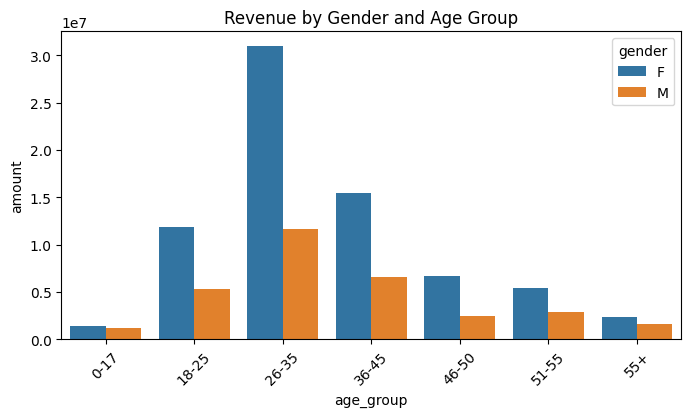

In [18]:
# Question 2: Which customer segment (Gender + Age Group) contributes the most revenue?
pivot = df.groupby(["gender", "age_group"])["amount"].sum().reset_index()

plt.figure(figsize=(8,4))
sns.barplot(data=pivot, x="age_group", y="amount", hue="gender")
plt.title("Revenue by Gender and Age Group")
plt.xticks(rotation=45)
plt.show()

### ❓ Question 3: Do married customers spend more than unmarried customers?

Analyzing the impact of marital status on spending can reveal family-oriented purchasing behavior during festivals.

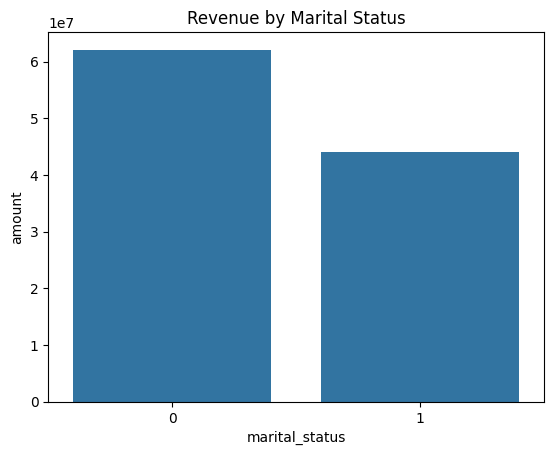

In [19]:
# Question 3: Do married customers spend more than unmarried customers?
marital = df.groupby("marital_status")["amount"].sum().reset_index()

sns.barplot(data=marital, x="marital_status", y="amount")
plt.title("Revenue by Marital Status")
plt.show()

### ❓ Question 4: Which top 5 states generate the highest revenue?

Identifying high-revenue states helps businesses focus region-specific marketing and logistics strategies.

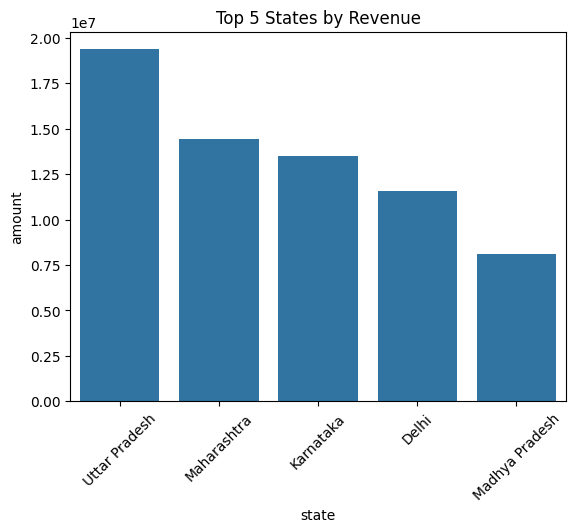

In [20]:
# Question 4: Which top 5 states generate the highest revenue?
region = df.groupby("state")["amount"].sum().nlargest(5).reset_index()
sns.barplot(data=region, x="state", y="amount")
plt.title("Top 5 States by Revenue")
plt.xticks(rotation=45)
plt.show()

### ❓ Question 5: Which zone contributes the most revenue and orders?

Comparing revenue vs. orders per zone helps identify whether some regions have high spending but low order volume (indicating premium buying behavior).

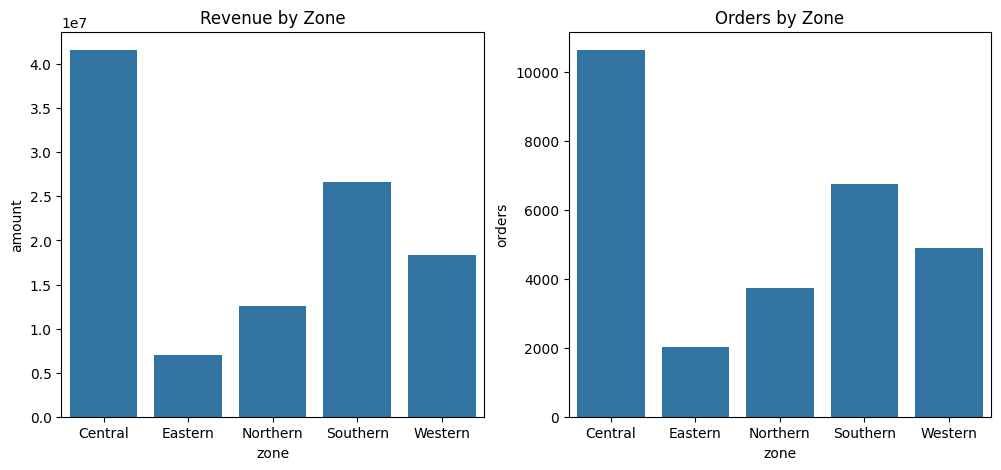

In [21]:
# Question 5: Which zone contributes the most revenue and orders?
zone_data = df.groupby("zone").agg({"amount":"sum", "orders":"sum"}).reset_index()

fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.barplot(data=zone_data, x="zone", y="amount", ax=ax[0])
ax[0].set_title("Revenue by Zone")

sns.barplot(data=zone_data, x="zone", y="orders", ax=ax[1])
ax[1].set_title("Orders by Zone")

plt.show()

### ❓ Question 6: Which occupation group has the highest average spending per user?

Average order value by occupation reveals which professional groups are the highest spenders — useful for premium targeting.

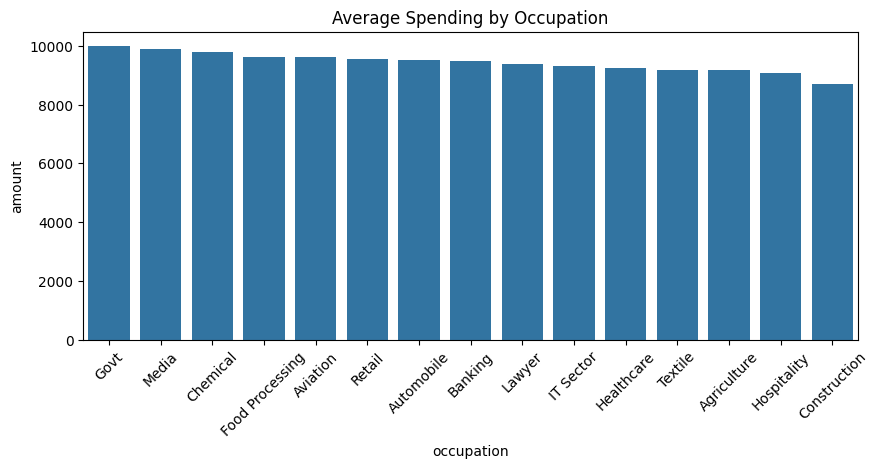

In [22]:
# Question 6: Which occupation group has the highest average spending per user?
occupation = df.groupby("occupation")["amount"].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10,4))
sns.barplot(data=occupation, x="occupation", y="amount")
plt.title("Average Spending by Occupation")
plt.xticks(rotation=45)
plt.show()

### ❓ Question 7: Which product category generates the highest revenue vs. highest orders?

> ⚠️ **Key Insight:** High Revenue ≠ High Demand.  
> Revenue-heavy categories may have expensive products, while high-order categories indicate popular everyday items.

This dual view helps in inventory planning and pricing strategy.

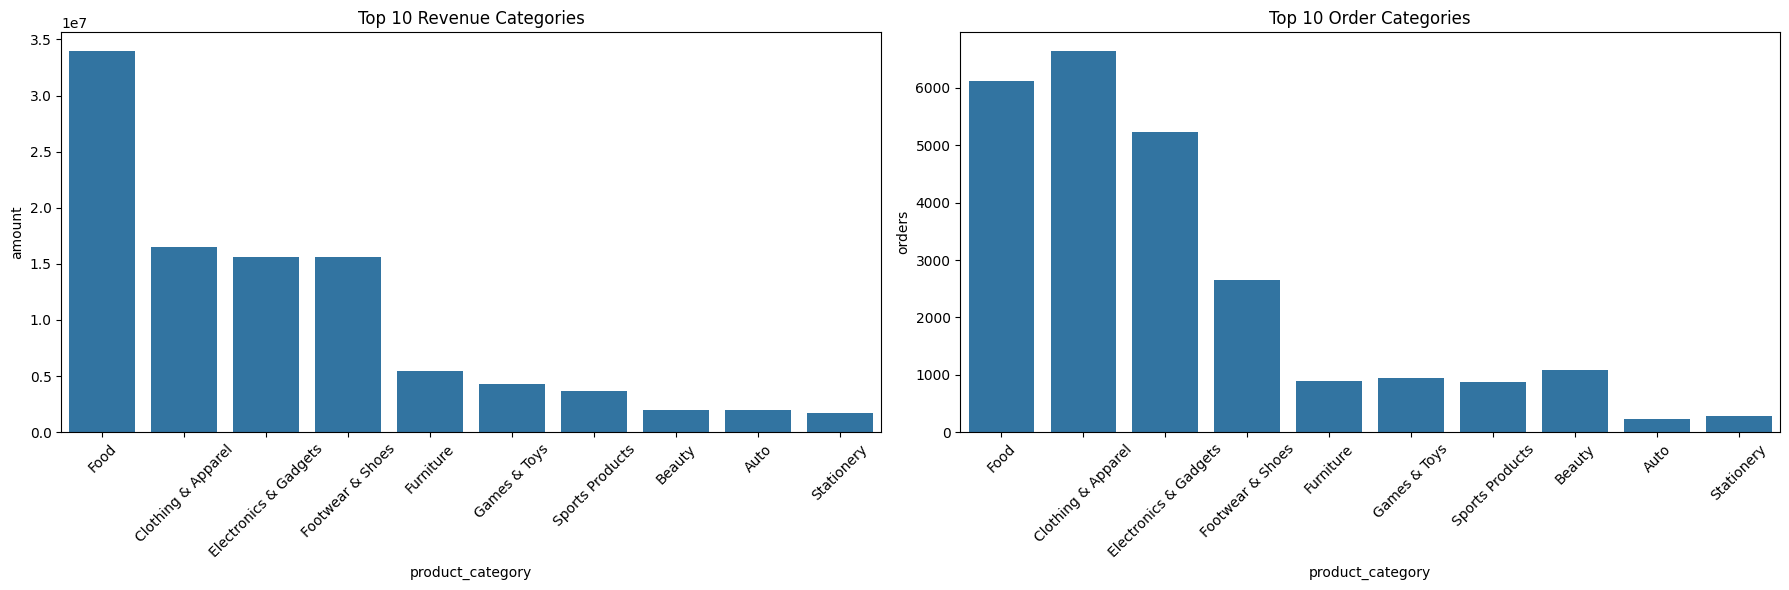

In [23]:
# Question 7: Which product category generates the highest revenue vs highest orders?
category = df.groupby("product_category").agg({
    "amount": "sum",
    "orders": "sum"
}).reset_index()
top_category = category.sort_values(by="amount", ascending=False).head(10)

fig, ax = plt.subplots(1,2, figsize=(18,6))

sns.barplot(data=top_category, x="product_category", y="amount", ax=ax[0])
ax[0].set_title("Top 10 Revenue Categories")
ax[0].tick_params(axis='x', rotation=45)

sns.barplot(data=top_category, x="product_category", y="orders", ax=ax[1])
ax[1].set_title("Top 10 Order Categories")
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### ❓ Question 8: What is the Average Order Value (AOV) across different customer segments?

AOV helps understand how much each customer spends per order on average, segmented by gender. This can guide discount and bundling strategies.

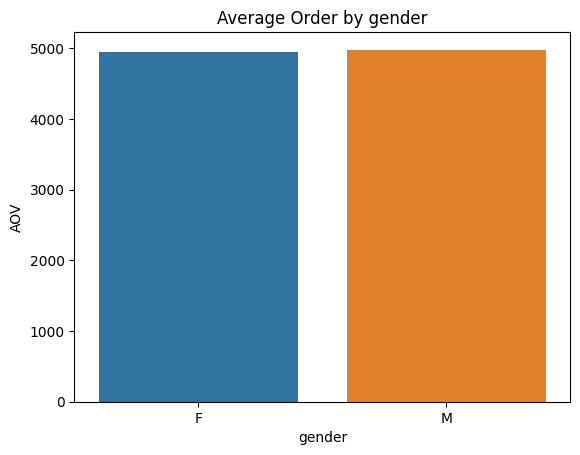

In [24]:
# Question 8: What is the Average Order Value (AOV) across different customer segments?
df["AOV"] = df["amount"] / df["orders"]
aov = df.groupby("gender")["AOV"].mean().reset_index()

sns.barplot(data=aov, x="gender", y="AOV" , hue="gender")
plt.title("Average Order by gender")
plt.show()

### ❓ Question 9: Who are the top 10 customers by total spending?

Identifying the highest-spending customers can help craft loyalty programs and personalized offers.

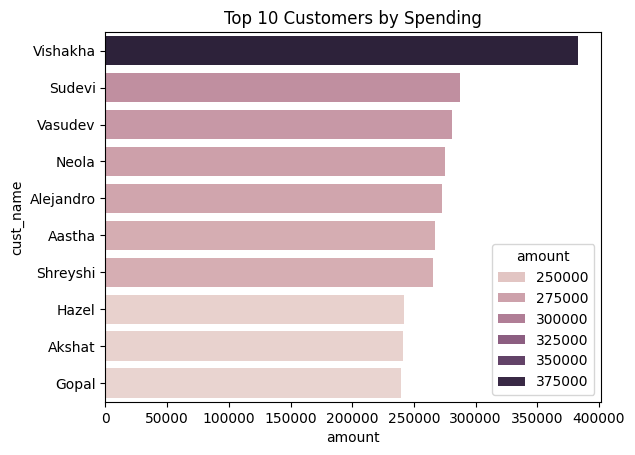

In [25]:
# Question 9: Who are the top 10 customers by total spending?
top_customer = df.groupby("cust_name")["amount"].sum().nlargest(10).reset_index()
sns.barplot(data=top_customer, x="amount" , y="cust_name" , hue="amount")
plt.title("Top 10 Customers by Spending")
plt.show()

### ❓ Question 10: Which State + Product Category combination drives the most revenue?

Understanding which state-category pairs generate the highest revenue allows for hyper-targeted regional marketing and stock allocation.

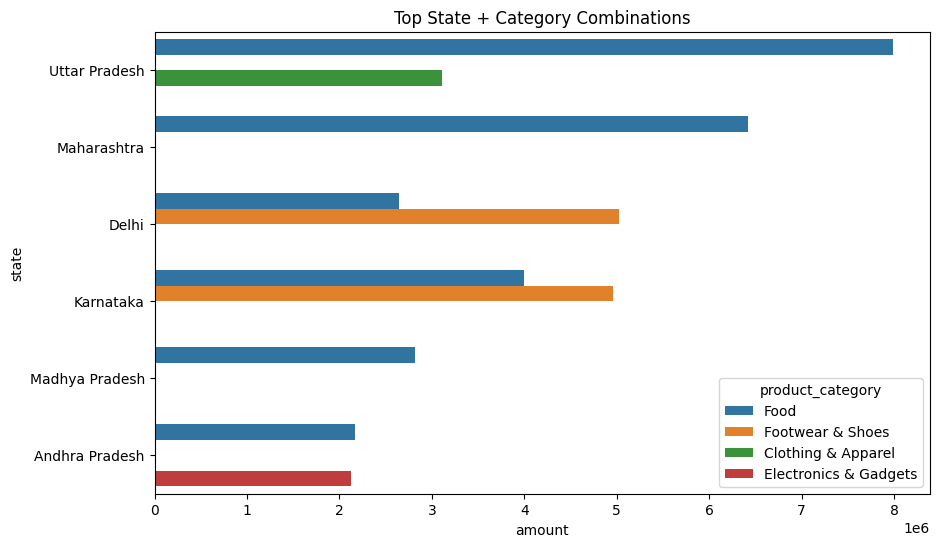

In [26]:
# Question 10: Which combination drives the most revenue?
combo = df.groupby(["state","product_category"])["amount"].sum().reset_index()

top_combo = combo.sort_values(by="amount", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_combo, x="amount", y="state", hue="product_category")
plt.title("Top State + Category Combinations")
plt.show()

---

## 🚀 Conclusion

This analysis provides meaningful insights into customer behavior during Diwali sales:

| Insight | Finding |
|---|---|
| 🎯 **Target Audience** | Age group **26–35** is the primary buyer segment |
| 👩 **Gender Contribution** | Female customers are major revenue contributors |
| 💍 **Marital Status** | Married customers tend to spend more |
| 🗺️ **Top Regions** | Certain states (e.g., Maharashtra, Uttar Pradesh) drive most revenue |
| 🛒 **Product Insight** | High revenue ≠ High demand — pricing strategy matters |

---

## 📌 Future Improvements
- Add predictive analysis (sales forecasting)
- Build an interactive dashboard (Power BI / Tableau)
- Perform customer segmentation using clustering

---

### 🙌 Author
**Mohd. Musaib Khan** — Aspiring Data Analyst | Frontend Developer